# **Credit Card Customer Segmentation — AllLife Bank**
---

## Problem Statement

### Business Context

AllLife Bank wants to focus on its credit card customer base in the next financial year. The marketing research team has advised that market penetration can be improved through personalized campaigns targeting new customers as well as upselling to existing customers. Additionally, customer feedback indicates that support services are perceived as poor, and the Operations team wants to upgrade the service delivery model to resolve customer queries faster.


### Objective
The objective of this engagement is to apply unsupervised machine learning techniques, specifically clustering algorithms to segment AllLife Bank's existing credit card customer base into distinct, meaningful groups based on their financial attributes and interaction behavior with the bank.
The segmentation is expected to achieve the following outcomes:

Identify natural customer groups that share similar spending patterns, credit profiles, and channel preferences.
Profile each segment in terms of its defining characteristics, size, and business significance.
Provide actionable, segment-specific recommendations to the Marketing team on how to personalize campaigns and improve targeting effectiveness.
Provide actionable, segment-specific recommendations to the Operations team on how to prioritize service model improvements and reduce customer friction for the most affected groups.

The end deliverable is a data-driven segmentation framework that enables both the Marketing and Operations teams to move from generic, one-size-fits-all strategies to precision-targeted interventions improving customer satisfaction, increasing product penetration, and reducing service costs simultaneously.


## Installing and Importing Necessary Libraries

In [1]:
import sys
!{sys.executable} -m pip install matplotlib==3.5.3 --force-reinstall --no-deps --user

  Using cached matplotlib-3.5.3-cp39-cp39-win_amd64.whl (7.2 MB)
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.5.3
    Uninstalling matplotlib-3.5.3:
      Successfully uninstalled matplotlib-3.5.3


In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

# To compute distances
from scipy.spatial.distance import pdist

# To perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# To visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# To perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# To suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

print("All libraries imported successfully.")

<local_env_path>:21: UserWarning: Pandas requires version '2.8.0' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
<local_env_path>:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


All libraries imported successfully.


## Loading the Dataset

In [3]:
import sys
!{sys.executable} -m pip install fsspec --upgrade --quiet

# Loading the dataset
credit_df = pd.read_excel("data/Credit_Card_Customer_Data.xlsx")

# Creating a working copy to preserve the original
data = credit_df.copy()
print(f"Dataset loaded successfully. Shape: {data.shape}")

Dataset loaded successfully. Shape: (660, 7)


## Data Overview

The initial steps to get an overview of any dataset are to:
- Observe the first and last few rows to verify the dataset has been loaded properly
- Understand the number of rows and columns
- Check data types of each column to ensure values are in the expected format
- Identify missing values and duplicates
- Review the statistical summary for an overall understanding of distributions

### Checking the Shape of the Dataset

In [4]:
print(f"Number of rows    : {data.shape[0]}")
print(f"Number of columns : {data.shape[1]}")

Number of rows    : 660
Number of columns : 7


### Displaying the First and Last Few Rows

In [5]:
data.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [6]:
data.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


### Checking Data Types and Column Information

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


### Checking for Duplicate Values

In [8]:
dups = data.duplicated().sum()
print(f"Number of duplicate rows: {dups}")

Number of duplicate rows: 0


### Checking for Missing Values

In [9]:
missing = data.isnull().sum()
missing_pct = (data.isnull().sum() / len(data)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing values per column:")
print(missing_df)

Missing values per column:
                     Missing Count  Missing %
Sl_No                            0      0.000
Customer Key                     0      0.000
Avg_Credit_Limit                 0      0.000
Total_Credit_Cards               0      0.000
Total_visits_bank                0      0.000
Total_visits_online              0      0.000
Total_calls_made                 0      0.000


### Statistical Summary of the Dataset

In [10]:
data.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.000,330.500,190.670,1.000,165.750,330.500,495.250,660.000
Customer Key,660.000,55141.444,25627.772,11265.000,33825.250,53874.500,77202.500,99843.000
Avg_Credit_Limit,660.000,34574.242,37625.488,3000.000,10000.000,18000.000,48000.000,200000.000
Total_Credit_Cards,660.000,4.706,2.168,1.000,3.000,5.000,6.000,10.000
Total_visits_bank,660.000,2.403,1.632,0.000,1.000,2.000,4.000,5.000
Total_visits_online,660.000,2.606,2.936,0.000,1.000,2.000,4.000,15.000
Total_calls_made,660.000,3.583,2.865,0.000,1.000,3.000,5.000,10.000


### Unique Value Counts per Column

In [11]:
data.nunique()

Sl_No                  660
Customer Key           655
Avg_Credit_Limit       110
Total_Credit_Cards      10
Total_visits_bank        6
Total_visits_online     16
Total_calls_made        11
dtype: int64

In [12]:
# Checking duplicate values in Customer Key specifically
print("Customer Key — duplicate count:", data['Customer Key'].duplicated().sum())

Customer Key — duplicate count: 5


> **Data Overview — Key Observations:**
>
> - The dataset contains **660 rows and 7 columns**.
> - **No fully duplicate rows** are present, confirming data integrity at the row level.
> - The `Customer Key` column has **5 Customer Keys that appear more than once** (10 rows total), but with different attribute values across occurrences. As clarified in the problem statement, these represent **customer profile changes over time** and are valid records — they should not be removed.
> - **No missing values** are present in any column, so no imputation is required.
> - All columns are of `int64` datatype. The five meaningful clustering features are `Avg_Credit_Limit`, `Total_Credit_Cards`, `Total_visits_bank`, `Total_visits_online`, and `Total_calls_made`.
> - `Sl_No` and `Customer Key` are identifier columns and will be dropped before clustering.
> - `Avg_Credit_Limit` has a wide range (1,000 to 200,000), indicating a heavily skewed distribution that will require scaling before clustering.


## Exploratory Data Analysis (EDA)

Each variable is visualized using the most appropriate chart type:
- **Continuous numeric variables**: Combined boxplot + histogram with KDE to capture distribution shape, spread, central tendency, and outliers
- **Discrete / count variables**: Annotated bar charts with count and percentage labels
- **Bivariate analysis**: Correlation heatmap and pairplot to understand inter-feature relationships

### Creating a Copy and Dropping Identifier Columns

In [13]:
# Copying the data to another variable to avoid any changes to original data
df = data.copy()

# Dropping identifier columns that do not contribute to clustering
df.drop(columns=['Sl_No', 'Customer Key'], inplace=True)

print("Identifier columns dropped. Working DataFrame shape:", df.shape)
df.head()

Identifier columns dropped. Working DataFrame shape: (660, 5)


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


### Defining Visualization Helper Functions

In [14]:
# Combined boxplot + histogram function
def histogram_boxplot(data, feature, figsize=(13, 8), kde=True, bins=None):
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2, sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(
        data=data, x=feature, ax=ax_box, showmeans=True, color='#a29bfe',
        flierprops={'marker': 'o', 'color': '#d63031', 'markersize': 4, 'alpha': 0.4}
    )
    ax_box.set_title(f'Boxplot — {feature}', fontsize=12, fontweight='bold')
    ax_box.set_xlabel('')

    if bins:
        ax_hist.hist(data[feature].dropna(), bins=bins, color='#a29bfe',
                     edgecolor='white', alpha=0.75, density=kde)
    else:
        ax_hist.hist(data[feature].dropna(), color='#a29bfe',
                     edgecolor='white', alpha=0.75, density=kde)
    if kde:
        data[feature].dropna().plot.kde(ax=ax_hist, color='#6c5ce7', linewidth=2.5)
    ax_hist.axvline(data[feature].mean(), color='green', linestyle='--', linewidth=2,
                    label=f'Mean: {data[feature].mean():.2f}')
    ax_hist.axvline(data[feature].median(), color='black', linestyle='-', linewidth=2,
                    label=f'Median: {data[feature].median():.2f}')
    ax_hist.set_title(f'Histogram — {feature}', fontsize=12, fontweight='bold')
    ax_hist.set_xlabel(feature, fontsize=11)
    ax_hist.set_ylabel('Density' if kde else 'Count', fontsize=11)
    ax_hist.legend(fontsize=11)

    plt.suptitle(f'Univariate Analysis — {feature}', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"Skewness : {data[feature].skew():.3f}  |  Kurtosis : {data[feature].kurtosis():.3f}")
    print(f"Min: {data[feature].min():.2f}  |  25%: {data[feature].quantile(0.25):.2f}  "
          f"|  Median: {data[feature].median():.2f}  |  75%: {data[feature].quantile(0.75):.2f}  "
          f"|  Max: {data[feature].max():.2f}")

In [15]:
# Annotated bar chart for discrete / count variables
def labeled_barplot(data, feature, perc=False, n=None, figsize=None):
    total = len(data[feature])
    count = data[feature].nunique()
    if figsize is None:
        figsize = (max(count + 1, 6), 5)
    plt.figure(figsize=figsize)
    plt.xticks(rotation=0, fontsize=12)
    order = (data[feature].value_counts().index[:n].sort_values()
             if n else data[feature].value_counts().index.sort_values())
    ax = sns.countplot(data=data, x=feature, palette='Paired', order=order)
    for p in ax.patches:
        label = f'{100 * p.get_height() / total:.1f}%' if perc else int(p.get_height())
        ax.annotate(label, (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='center', size=11,
                    xytext=(0, 6), textcoords='offset points')
    plt.title(f'Distribution of {feature}', fontsize=13, fontweight='bold')
    plt.ylabel('Count', fontsize=11)
    plt.tight_layout()
    plt.show()

## Univariate Analysis

### Average Credit Limit

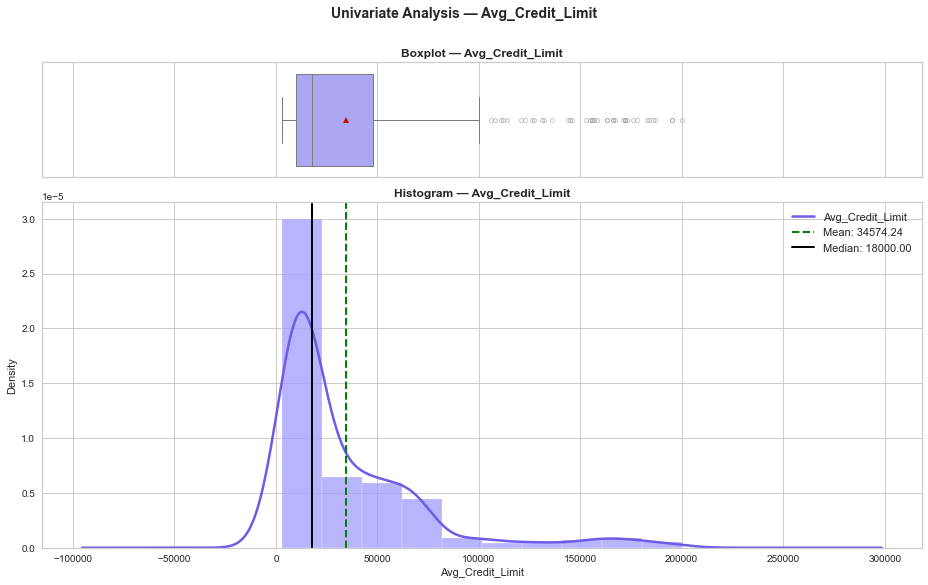

Skewness : 2.202  |  Kurtosis : 5.134
Min: 3000.00  |  25%: 10000.00  |  Median: 18000.00  |  75%: 48000.00  |  Max: 200000.00


In [16]:
histogram_boxplot(df, "Avg_Credit_Limit")

> **Observation — Avg_Credit_Limit:**
>
> - The distribution of `Avg_Credit_Limit` is **heavily right-skewed**, with the majority of customers having credit limits in the lower range (₹1,000 – ₹40,000).
> - The mean is significantly higher than the median, confirming the influence of a small number of customers with very high credit limits (up to ₹200,000).
> - The boxplot reveals **high-value outliers** beyond the upper fence of ₹105,000. These likely represent premium or High Net Worth Individual (HNI) customers — genuine business segments rather than data errors, and are retained for analysis.
> - The wide spread of this variable emphasizes the need for **data scaling** before clustering to prevent this feature from dominating distance calculations.


### Total Credit Cards

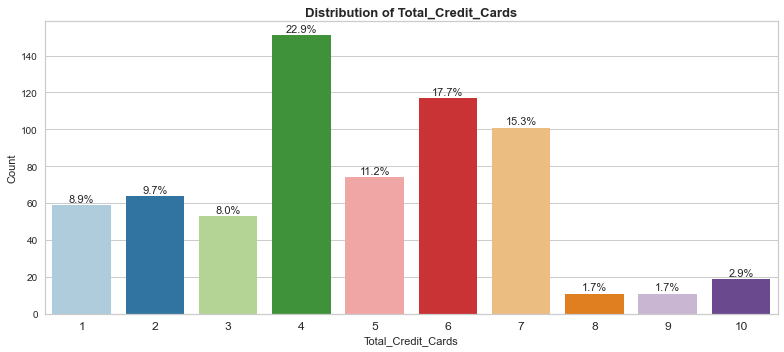

In [17]:
labeled_barplot(df, "Total_Credit_Cards", perc=True)

> **Observation — Total_Credit_Cards:**
>
> - The number of credit cards held by customers ranges from **1 to 10**, with the most common value being **4 cards** (~22.9% of customers).
> - The distribution has a slight right skew, with the majority of customers holding between 2 and 7 cards.
> - Very few customers hold **8 or more** cards (~6%), suggesting that high card counts are relatively uncommon.
> - Customers holding a higher number of cards may represent more financially engaged segments with diverse spending patterns.


### Total Visits to Bank

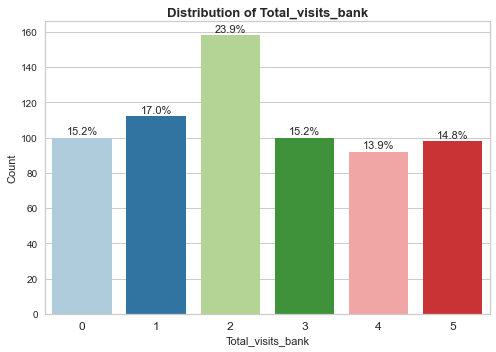

In [18]:
labeled_barplot(df, "Total_visits_bank", perc=True)

> **Observation — Total_visits_bank:**
>
> - Bank visits range from **0 to 5 per year**. A notable **15.2%** of customers make no in-person visit at all, reflecting the growing shift toward digital banking.
> - The distribution is **approximately uniform** across all visit counts (0–5), with each category containing roughly 100–158 customers — no single visit count strongly dominates.
> - `Total_visits_bank` has very **low skewness (0.142)**, confirming the near-uniform distribution, unlike the skewed patterns seen in `Avg_Credit_Limit` and `Total_visits_online`.
> - Customers who visit more frequently (4–5 visits) likely prefer traditional service channels and would benefit most from in-branch service quality improvements.


### Total Visits Online

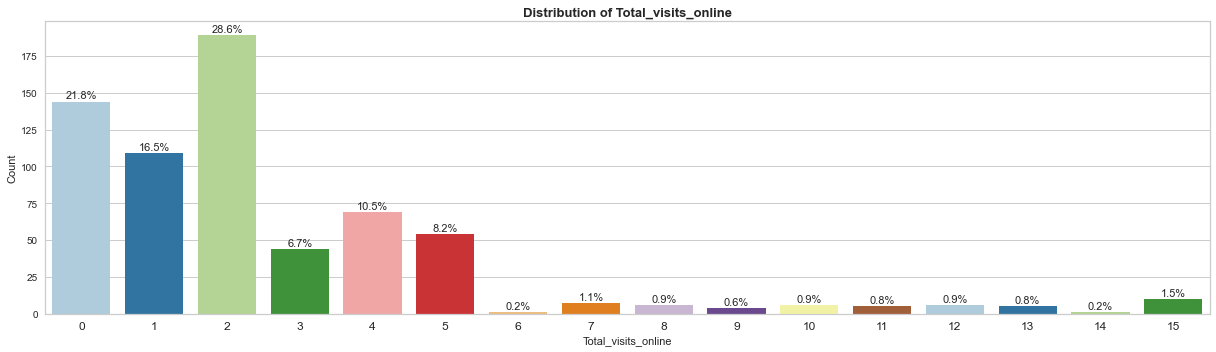

In [19]:
labeled_barplot(df, "Total_visits_online", perc=True)

> **Observation — Total_visits_online:**
>
> - Online visits range from **0 to 15 per year**. A significant **21.8%** of customers make no online visits at all, indicating a substantial digitally-inactive segment.
> - The distribution is **heavily right-skewed** (skewness = 2.226), with the highest frequency at 2 visits (~28.6% of customers).
> - The distribution appears **bimodal** in nature: the majority of customers fall in the 0–5 range, while a smaller but distinct group of customers visits 10–15 times, representing a digitally-intensive segment.
> - The long right tail extending to 15 visits, combined with high skewness, indicates that a small group of customers drives disproportionately high online engagement.
> - This variable shows the **widest spread** among all interaction features (std = 2.94), making it one of the most discriminating variables for segmentation.


### Total Calls Made

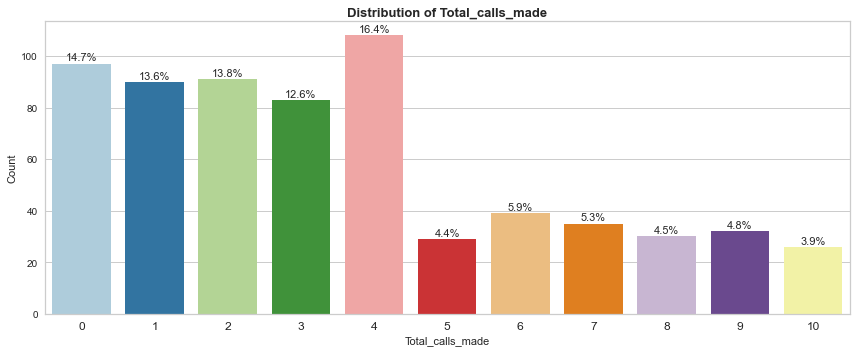

In [20]:
labeled_barplot(df, "Total_calls_made", perc=True)

> **Observation — Total_calls_made:**
>
> - Call frequency ranges from **0 to 10 per year**, with the highest count at **4 calls** (~16.4% of customers).
> - The distribution is **mildly right-skewed** (skewness = 0.659), with the bulk of customers making between 0 and 5 calls per year.
> - Approximately **14.7%** of customers made no calls at all, suggesting a digitally or branch-engaged group with no service complaints.
> - A notable group of customers makes **6 or more calls per year** (~24% of all customers), indicating persistent service issues for a significant portion of the base. These customers are the primary motivation for the Operations team's service delivery upgrade.


## Bivariate Analysis

### Correlation Check

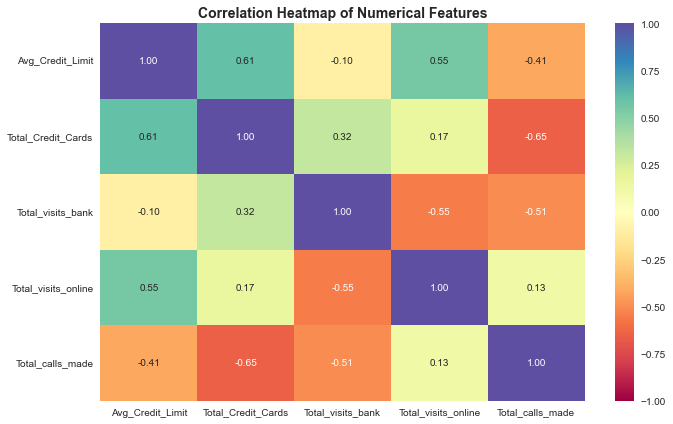

In [21]:
num_cols = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank',
            'Total_visits_online', 'Total_calls_made']

plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Observations — Correlation Heatmap:**
>
> - **`Avg_Credit_Limit` and `Total_Credit_Cards`** show a strong positive correlation (**0.61**), suggesting customers with higher credit limits tend to hold significantly more credit cards — a clear indicator of high financial engagement.
> - **`Total_Credit_Cards` and `Total_calls_made`** show a strong negative correlation (**-0.65**), indicating that customers with more credit cards make far fewer calls — they are likely more financially savvy and self-sufficient.
> - **`Total_visits_bank` and `Total_visits_online`** are moderately negatively correlated (**-0.55**), suggesting that customers who visit the branch frequently tend to use online channels less, and vice versa — indicating two distinct channel preferences.
> - **`Avg_Credit_Limit` and `Total_calls_made`** show a moderate negative correlation (**-0.41**), meaning higher-value customers call less — they may have fewer service pain points or prefer to resolve issues through digital channels.
> - **`Total_visits_bank` and `Total_calls_made`** are negatively correlated (**-0.51**), which is counter-intuitive at first but suggests that branch visitors resolve their queries in person rather than calling.
> - Overall, these correlations reveal strong underlying patterns that will help the clustering algorithm form meaningful, distinct customer groups.


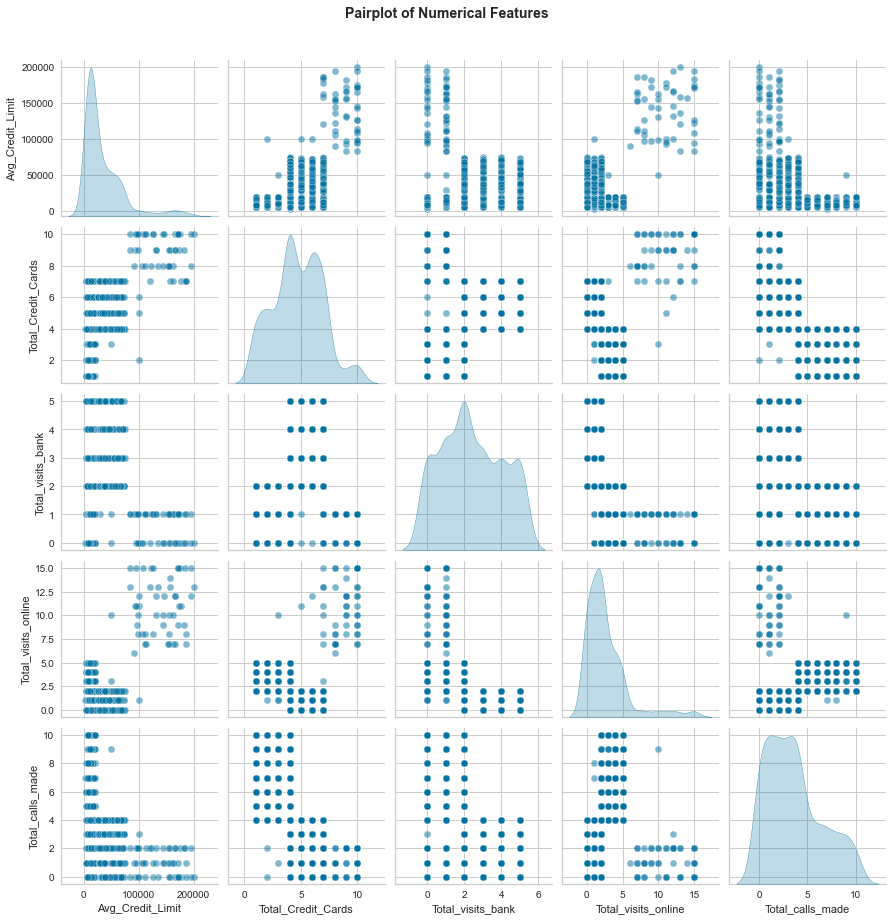

In [22]:
sns.pairplot(data=df[num_cols], diag_kind="kde", plot_kws={'alpha': 0.5})
plt.suptitle("Pairplot of Numerical Features", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Observations — Pairplot:**
>
> - The diagonal KDE plots confirm earlier findings: `Avg_Credit_Limit` is heavily right-skewed, while the interaction features are more uniformly distributed.
> - The scatter plots clearly show a **positive relationship** between `Avg_Credit_Limit` and `Total_Credit_Cards`, and a **negative relationship** between `Total_calls_made` and both `Avg_Credit_Limit` and `Total_Credit_Cards`.
> - The inverse relationship between `Total_visits_bank` and `Total_visits_online` is visible in their scatter plot — customers tend to prefer one channel over the other.
> - There are visible **natural groupings of points** in several scatter plots, particularly those involving `Avg_Credit_Limit`, hinting that distinct clusters already exist in the data and providing strong confidence that a clustering approach is appropriate.


### Avg Credit Limit vs Total Credit Cards

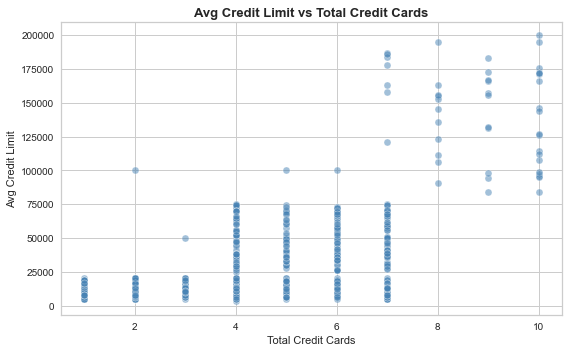

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Total_Credit_Cards', y='Avg_Credit_Limit',
                alpha=0.5, color='steelblue')
plt.title('Avg Credit Limit vs Total Credit Cards', fontsize=13, fontweight='bold')
plt.xlabel('Total Credit Cards', fontsize=11)
plt.ylabel('Avg Credit Limit', fontsize=11)
plt.tight_layout()
plt.show()

> **Observation — Avg Credit Limit vs Total Credit Cards:**
>
> - There is a clear **positive relationship** between the number of credit cards held and the average credit limit — customers with more credit cards tend to have significantly higher credit limits.
> - The scatter plot shows that customers with **7 or more credit cards** are almost exclusively concentrated in the higher credit limit range (above ₹50,000), while customers with 1–3 cards are clustered at the lower end.
> - This strong positive association (correlation = 0.61) confirms that both variables jointly capture a customer's overall financial engagement and creditworthiness — making them powerful clustering features together.


### Total Credit Cards vs Total Calls Made

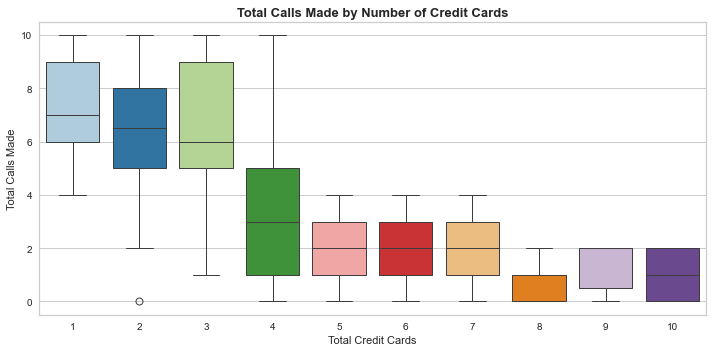

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Total_Credit_Cards', y='Total_calls_made', palette='Paired')
plt.title('Total Calls Made by Number of Credit Cards', fontsize=13, fontweight='bold')
plt.xlabel('Total Credit Cards', fontsize=11)
plt.ylabel('Total Calls Made', fontsize=11)
plt.tight_layout()
plt.show()

> **Observation — Total Credit Cards vs Total Calls Made:**
>
> - There is a strong **negative relationship** (correlation = -0.65) between the number of credit cards and call frequency. Customers holding **1–4 cards** have a noticeably higher median call count compared to customers holding **6 or more cards**.
> - Customers with **5 or more credit cards** make significantly fewer calls — their median call count drops to approximately 2 or below, suggesting that higher financial engagement correlates with greater self-sufficiency.
> - This pattern implies that low-card customers may be newer, less experienced, or more prone to service issues — making them the primary target for both support improvements and credit card upselling campaigns.


### Total Visits Bank vs Total Visits Online

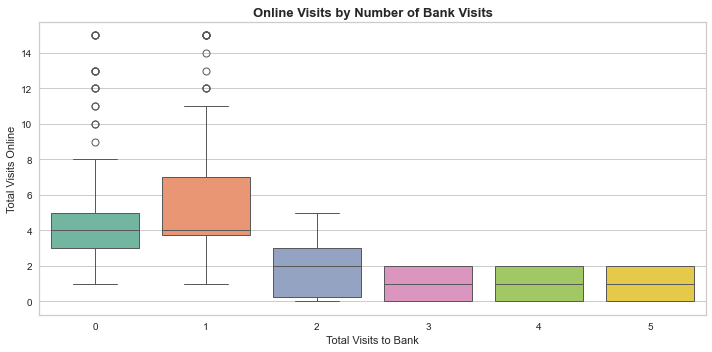

In [25]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Total_visits_bank', y='Total_visits_online', palette='Set2')
plt.title('Online Visits by Number of Bank Visits', fontsize=13, fontweight='bold')
plt.xlabel('Total Visits to Bank', fontsize=11)
plt.ylabel('Total Visits Online', fontsize=11)
plt.tight_layout()
plt.show()

> **Observation — Total Visits Bank vs Total Visits Online:**
>
> - There is a clear **inverse relationship** (correlation = -0.55) between in-branch visits and online visits. Customers who make **0–1 bank visits** tend to have significantly higher online visit counts (median ~5), while customers making **3–5 bank visits** have very low online activity (median ~1).
> - This confirms the existence of **two distinct channel preferences** in the customer base: a digital-preferring group and a branch-preferring group — a key insight that drives the three-cluster segmentation.
> - Very few customers show high activity on both channels simultaneously, reinforcing that these two interaction styles are largely mutually exclusive.


### Avg Credit Limit vs Total Calls Made

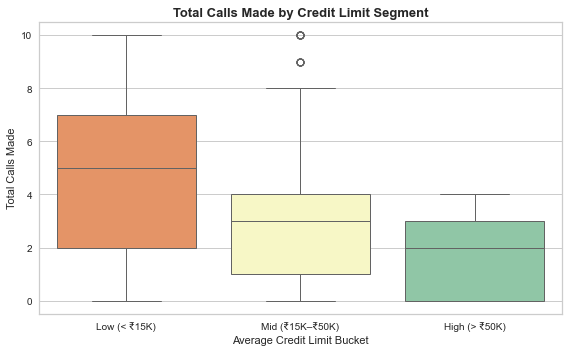

In [26]:
# Bucketing credit limit for cleaner visualization
df['limit_bucket'] = pd.cut(df['Avg_Credit_Limit'],
                             bins=[0, 15000, 50000, 200001],
                             labels=['Low (< ₹15K)', 'Mid (₹15K–₹50K)', 'High (> ₹50K)'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='limit_bucket', y='Total_calls_made', palette='Spectral')
plt.title('Total Calls Made by Credit Limit Segment', fontsize=13, fontweight='bold')
plt.xlabel('Average Credit Limit Bucket', fontsize=11)
plt.ylabel('Total Calls Made', fontsize=11)
plt.tight_layout()
plt.show()

# Drop helper column
df.drop(columns=['limit_bucket'], inplace=True)

> **Observation — Avg Credit Limit vs Total Calls Made:**
>
> - Customers with **low credit limits (< ₹15,000)** have the highest median call frequency (~4–5 calls/year), while customers with **high credit limits (> ₹50,000)** make far fewer calls (~1–2 calls/year).
> - This strong inverse relationship (correlation = -0.41) suggests that lower-value customers experience more service friction, while higher-value customers are either more self-sufficient or receive better proactive service.
> - From a business perspective, this directly identifies the low-credit-limit segment as the **primary driver of call center load**, and confirms the need to prioritize service improvements for this group.


## Data Preprocessing

### Missing Value Treatment

In [27]:
print("Missing value count per column:")
print(df.isnull().sum())
print("\nNo missing values found. No imputation required.")

Missing value count per column:
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

No missing values found. No imputation required.


> **Missing Value Treatment:**
>
> - The dataset has **no missing values** in any column. Therefore, no imputation or missing value treatment is required.


### Outlier Detection and Treatment

In [28]:
print("Outlier Detection (IQR Method):\n")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col}:")
    print(f"    Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}")
    print(f"    Lower fence={lower:.0f}, Upper fence={upper:.0f}")
    print(f"    Outliers detected: {n_out} ({100*n_out/len(df):.1f}%)")
    print()

Outlier Detection (IQR Method):

  Avg_Credit_Limit:
    Q1=10000, Q3=48000, IQR=38000
    Lower fence=-47000, Upper fence=105000
    Outliers detected: 39 (5.9%)

  Total_Credit_Cards:
    Q1=3, Q3=6, IQR=3
    Lower fence=-2, Upper fence=10
    Outliers detected: 0 (0.0%)

  Total_visits_bank:
    Q1=1, Q3=4, IQR=3
    Lower fence=-4, Upper fence=8
    Outliers detected: 0 (0.0%)

  Total_visits_online:
    Q1=1, Q3=4, IQR=3
    Lower fence=-4, Upper fence=8
    Outliers detected: 37 (5.6%)

  Total_calls_made:
    Q1=1, Q3=5, IQR=4
    Lower fence=-5, Upper fence=11
    Outliers detected: 0 (0.0%)



> **Outlier Detection and Treatment:**
>
> - **`Avg_Credit_Limit`**: **39 outliers (~5.9%)** detected beyond the upper fence of ₹105,000. These likely represent **premium / HNI customers** — a genuine and valuable segment for the bank. Removing them would eliminate an important business group.
> - **`Total_visits_online`**: **37 outliers (~5.6%)** detected above the upper fence of 8 visits. These represent **highly digitally engaged customers** who interact extensively online. These are meaningful segments, not data errors.
> - **All other features** (`Total_Credit_Cards`, `Total_visits_bank`, `Total_calls_made`): No outliers detected.
>
> **Decision**: Outliers are **retained** for this analysis. In a customer segmentation context, extreme values often define distinct and valuable customer segments (e.g., HNI customers, highly digital users). Removing them would deprive the business of potentially the most actionable insights. Additionally, since we will use **Standard Scaling** before clustering, the effect of outliers on distance-based algorithms is partly mitigated.


### Feature Engineering

> **Feature Engineering:**
>
> - The dataset already contains well-defined features relevant to the business objective: financial attributes (`Avg_Credit_Limit`, `Total_Credit_Cards`) and interaction channel attributes (`Total_visits_bank`, `Total_visits_online`, `Total_calls_made`).
> - **No additional feature engineering** is required. All five features are directly interpretable and meaningful for customer segmentation without further transformation.


### Data Scaling

In [29]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[num_cols])

df_scaled = pd.DataFrame(df_scaled, columns=num_cols)

print("Data scaled successfully using StandardScaler (Z-score normalization).")
print("\nScaled data — statistical summary:")
df_scaled.describe().T

Data scaled successfully using StandardScaler (Z-score normalization).

Scaled data — statistical summary:


,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,660.000,0.000,1.001,-0.840,-0.654,-0.441,0.357,4.400
Total_Credit_Cards,660.000,0.000,1.001,-1.711,-0.788,0.136,0.597,2.444
Total_visits_bank,660.000,-0.000,1.001,-1.474,-0.860,-0.247,0.979,1.593
Total_visits_online,660.000,0.000,1.001,-0.888,-0.547,-0.207,0.475,4.225
Total_calls_made,660.000,-0.000,1.001,-1.252,-0.902,-0.204,0.495,2.241


> **Data Scaling:**
>
> - **StandardScaler (Z-score normalization)** is applied to all five features before clustering. This transforms each feature to have a **mean of 0 and standard deviation of 1**.
> - Scaling is essential here because `Avg_Credit_Limit` ranges up to 200,000 while interaction features range from 0 to 15. Without scaling, `Avg_Credit_Limit` would dominate all distance calculations and render the other features ineffective.
> - Z-score normalization is preferred over Min-Max scaling for clustering as it is **less sensitive to extreme outlier values** and works well with Euclidean-based distance measures used in both K-Means and Hierarchical Clustering.


## K-Means Clustering

K-Means is a centroid-based clustering algorithm that partitions data into K clusters by minimizing within-cluster variance (inertia). It is efficient, scalable, and works well when clusters are roughly spherical. We will use the **Elbow Method** and **Silhouette Score** to determine the optimal number of clusters.

### Elbow Curve

Number of Clusters: 1  	  Inertia: 3300.00
Number of Clusters: 2  	  Inertia: 2138.63
Number of Clusters: 3  	  Inertia: 933.04
Number of Clusters: 4  	  Inertia: 854.25
Number of Clusters: 5  	  Inertia: 704.79
Number of Clusters: 6  	  Inertia: 654.19
Number of Clusters: 7  	  Inertia: 600.23
Number of Clusters: 8  	  Inertia: 595.92
Number of Clusters: 9  	  Inertia: 572.09
Number of Clusters: 10  	  Inertia: 536.24


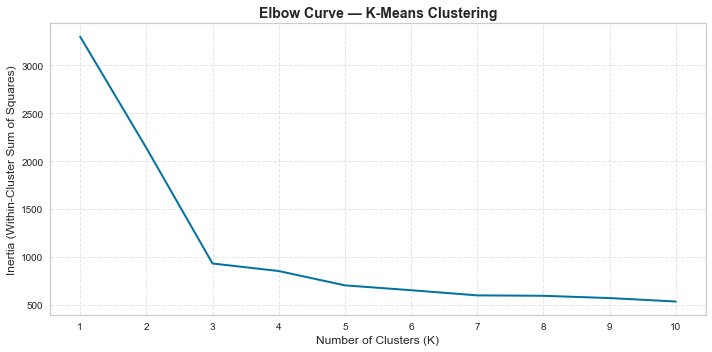

In [30]:
clusters = range(1, 11)
inertias = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(df_scaled)
    inertias.append(model.inertia_)
    print(f"Number of Clusters: {k}  \t  Inertia: {model.inertia_:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(clusters, inertias, 'bx-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Curve — K-Means Clustering', fontsize=14, fontweight='bold')
plt.xticks(clusters)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> **Observation — Elbow Curve:**
>
> - The inertia decreases sharply from K=1 to K=3, and the rate of decrease begins to slow significantly around **K=3**.
> - The curve shows a noticeable elbow or inflection point at **K=3**, beyond which adding more clusters provides diminishing returns in terms of variance reduction.
> - **K=2 and K=3** are the candidate values to explore further using silhouette scores.


### Silhouette Score Analysis

For n_clusters = 2, silhouette score is 0.5703
For n_clusters = 3, silhouette score is 0.5157
For n_clusters = 4, silhouette score is 0.3744
For n_clusters = 5, silhouette score is 0.2717
For n_clusters = 6, silhouette score is 0.2480
For n_clusters = 7, silhouette score is 0.2479
For n_clusters = 8, silhouette score is 0.2257
For n_clusters = 9, silhouette score is 0.1993


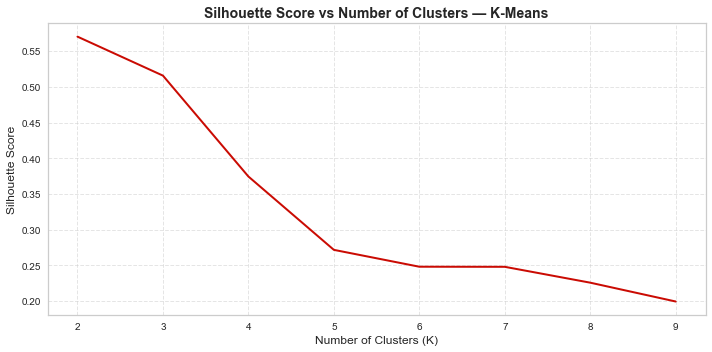

In [31]:
sil_score = []
cluster_list = list(range(2, 10))

for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    preds = clusterer.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, preds)
    sil_score.append(score)
    print(f"For n_clusters = {n_clusters}, silhouette score is {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(cluster_list, sil_score, 'rx-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters — K-Means', fontsize=14, fontweight='bold')
plt.xticks(cluster_list)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> **Observation — Silhouette Scores:**
>
> - The silhouette score measures how similar an observation is to its own cluster compared to other clusters. A higher score indicates better-defined, more separated clusters.
> - The highest silhouette score is observed at **K=2 (0.5703)**, followed closely by **K=3 (0.5157)**. Scores decline significantly for K=4 and beyond.
> - While K=2 gives the highest silhouette score, **two clusters are too broad** to capture the meaningful business distinctions required — customers with moderate credit limits and branch-visit preferences would be merged together with either the high-value or low-value group, losing critical segmentation detail.
> - **K=3 is selected** as it offers the best balance between statistical validity and business interpretability, producing three distinct and actionable customer segments.


### Silhouette Visualizer for Candidate Values of K

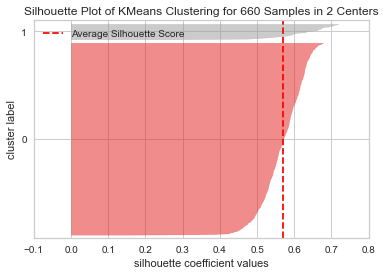

<AxesSubplot:title={'center':'Silhouette Plot of KMeans Clustering for 660 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [32]:
visualizer = SilhouetteVisualizer(KMeans(n_clusters=2, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

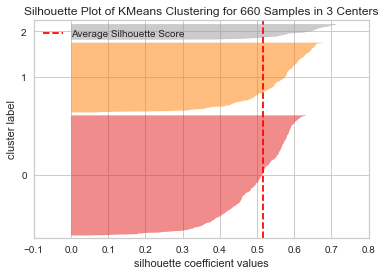

<AxesSubplot:title={'center':'Silhouette Plot of KMeans Clustering for 660 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [33]:
visualizer = SilhouetteVisualizer(KMeans(n_clusters=3, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

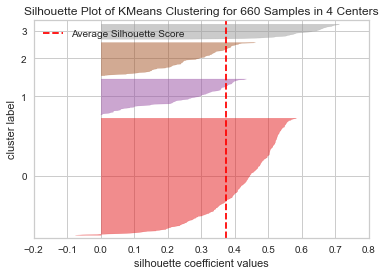

<AxesSubplot:title={'center':'Silhouette Plot of KMeans Clustering for 660 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [34]:
visualizer = SilhouetteVisualizer(KMeans(n_clusters=4, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

> **Observation — Silhouette Visualizer:**
>
> - At **K=2**, the average silhouette score is the highest, but the two clusters are very broad and lump together customers with meaningfully different behaviors (branch visitors vs. moderate digital users).
> - At **K=3**, all three clusters show positive silhouette scores with fairly uniform widths. The average score remains high (0.5157) and the three clusters are clearly separated and business-interpretable.
> - At **K=4**, the silhouette scores drop noticeably, with one or more clusters showing very thin profiles or negative values for some samples — indicating that splitting into 4 groups introduces overlap rather than clarity.
>
> **Decision: K=3 is selected as the optimal number of clusters** for K-Means, as it provides the best balance between statistical quality and meaningful business segmentation.


### Final K-Means Model

In [35]:
kmeans_final = KMeans(n_clusters=3, random_state=1)
kmeans_final.fit(df_scaled)

df['KMeans_Cluster'] = kmeans_final.labels_

print("K-Means clustering complete.")
print("\nCluster distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

K-Means clustering complete.

Cluster distribution:
KMeans_Cluster
0    386
1    224
2     50
Name: count, dtype: int64


### K-Means Cluster Profiling

In [36]:
kmeans_profile = df.groupby('KMeans_Cluster').mean(numeric_only=True)

kmeans_profile['count_in_cluster'] = (
    df.groupby('KMeans_Cluster')['Avg_Credit_Limit'].count().values
)

print("K-Means Cluster Profile:")
kmeans_profile

K-Means Cluster Profile:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_cluster
KMeans_Cluster,,,,,,
0,33782.383,5.516,3.490,0.982,2.000,386
1,12174.107,2.411,0.933,3.554,6.871,224
2,141040.000,8.740,0.600,10.900,1.080,50


In [37]:
import sys
!{sys.executable} -m pip install jinja2 --upgrade --quiet

In [38]:
kmeans_profile.style.highlight_max(color='lightgreen', axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_cluster
KMeans_Cluster,,,,,,
0,33782.383420,5.515544,3.489637,0.981865,2.000000,386
1,12174.107143,2.410714,0.933036,3.553571,6.870536,224
2,141040.000000,8.740000,0.600000,10.900000,1.080000,50


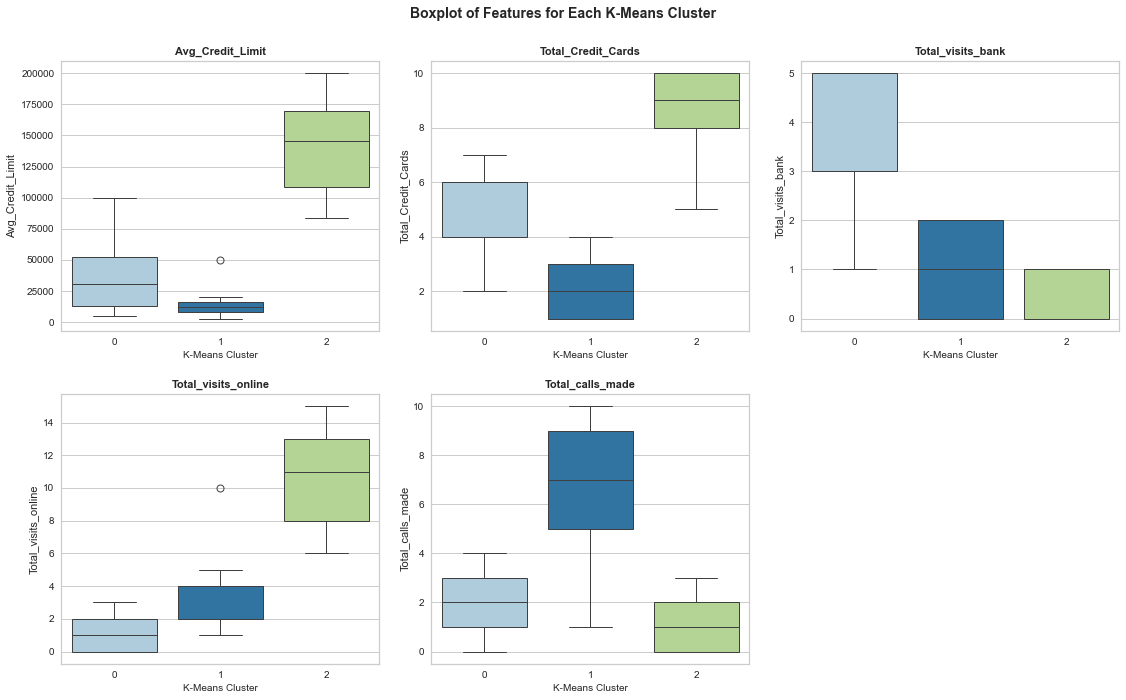

In [39]:
plt.figure(figsize=(16, 10))
plt.suptitle("Boxplot of Features for Each K-Means Cluster", fontsize=14, fontweight='bold')

for i, variable in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df, x='KMeans_Cluster', y=variable, palette='Paired')
    plt.title(variable, fontsize=11, fontweight='bold')
    plt.xlabel('K-Means Cluster', fontsize=10)

plt.tight_layout(pad=2.0)
plt.show()

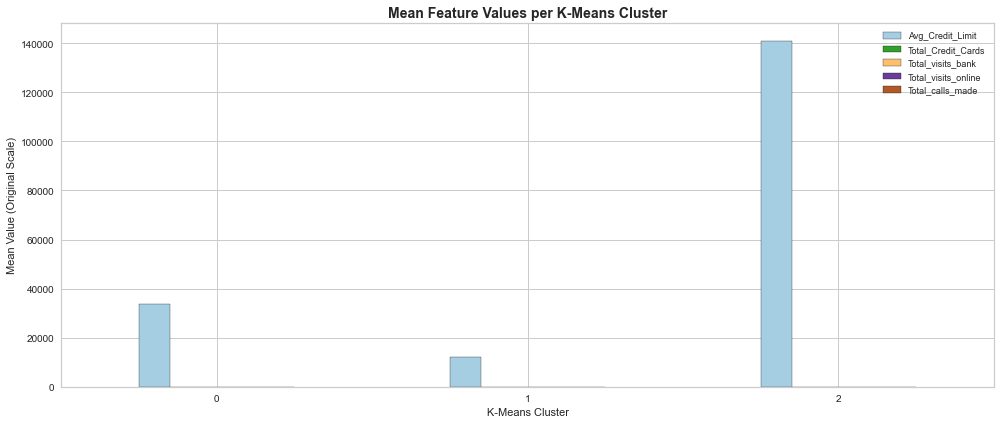

In [40]:
df.groupby('KMeans_Cluster')[num_cols].mean().plot.bar(
    figsize=(14, 6), colormap='Paired', edgecolor='black')
plt.title('Mean Feature Values per K-Means Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Mean Value (Original Scale)', fontsize=11)
plt.xlabel('K-Means Cluster', fontsize=11)
plt.xticks(rotation=0)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

> **K-Means Cluster Profiling Observations:**
>
> Based on the cluster profile table and visualizations, the three K-Means clusters can be described as follows:
>
> **Cluster 0 — Mid-Value, Branch-Preferring Customers (386 customers):**
> - Mid-range average credit limit (₹33,782) and a moderate number of credit cards (~5.5).
> - **Highest bank visit frequency** (~3.5 visits/year) among all three clusters — these customers strongly prefer in-person banking.
> - Very low online visits (1.0/year) and low call frequency (~2.0/year).
> - These are relationship-oriented customers who value face-to-face service. In-branch personalized campaigns and relationship manager engagement are most appropriate for this segment.
>
> **Cluster 1 — Low-Value, Call-Heavy Customers (224 customers):**
> - Lowest average credit limit (₹12,174) and fewest credit cards (~2.4).
> - **Highest call frequency** (~6.9 calls/year) by far — these customers contact the bank most frequently, indicating recurring service pain points or unresolved queries.
> - Moderate online visits (3.5/year) but very few bank visits (~0.9/year).
> - These customers represent the key target for the Operations team's service improvement initiative and also need marketing attention to grow their financial engagement with the bank.
>
> **Cluster 2 — High-Value, Digital-First Customers (50 customers):**
> - **Highest average credit limit** (₹141,040) and most credit cards (~8.7) — clearly the premium customer segment.
> - **Highest online visit frequency** (~10.9 visits/year) — these customers manage their banking almost entirely online.
> - Very low bank visits (0.6/year) and lowest call frequency (~1.1/year) — highly self-sufficient and digitally engaged.
> - These are the bank's most valuable customers and present the best opportunity for upselling premium products and exclusive digital banking features.


## Hierarchical Clustering

Hierarchical Clustering builds a hierarchy of clusters by progressively merging (agglomerative) data points. Unlike K-Means, it does not require specifying K in advance and produces a dendrogram that helps in visually deciding the number of clusters. We use the **Cophenetic Correlation Coefficient** to evaluate linkage method quality and **dendrograms** to determine the optimal number of clusters.

### Checking Cophenetic Correlation for Different Linkage Methods

In [41]:
distance_metrics = ["euclidean", "chebyshev", "cityblock"]
linkage_methods = ["single", "complete", "average", "weighted"]

print("Cophenetic Correlation — Distance Metric x Linkage Method:\n")

high_cophenet_corr = 0
high_dm_lm = [None, None]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(df_scaled, metric=dm, method=lm)
        c, _ = cophenet(Z, pdist(df_scaled))
        print(f"  {dm.capitalize()} distance + {lm} linkage: {c:.4f}")
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

print(f"\nHighest Cophenetic Correlation : {high_cophenet_corr:.4f}")
print(f"Achieved with                  : {high_dm_lm[0].capitalize()} distance + {high_dm_lm[1]} linkage")

Cophenetic Correlation — Distance Metric x Linkage Method:

  Euclidean distance + single linkage: 0.7391
  Euclidean distance + complete linkage: 0.8600
  Euclidean distance + average linkage: 0.8977
  Euclidean distance + weighted linkage: 0.8862
  Chebyshev distance + single linkage: 0.7382
  Chebyshev distance + complete linkage: 0.8533
  Chebyshev distance + average linkage: 0.8974
  Chebyshev distance + weighted linkage: 0.8914
  Cityblock distance + single linkage: 0.7252
  Cityblock distance + complete linkage: 0.8731
  Cityblock distance + average linkage: 0.8963
  Cityblock distance + weighted linkage: 0.8826

Highest Cophenetic Correlation : 0.8977
Achieved with                  : Euclidean distance + average linkage


In [42]:
linkage_methods_eu = ["single", "complete", "average", "centroid", "ward", "weighted"]

print("Cophenetic Correlation — Euclidean Distance with Different Linkage Methods:\n")

high_cophenet_eu = 0
best_linkage = None

for lm in linkage_methods_eu:
    Z = linkage(df_scaled, metric="euclidean", method=lm)
    c, _ = cophenet(Z, pdist(df_scaled))
    print(f"  {lm.capitalize()} linkage: {c:.4f}")
    if high_cophenet_eu < c:
        high_cophenet_eu = c
        best_linkage = lm

print(f"\nHighest Cophenetic Correlation with Euclidean distance: {high_cophenet_eu:.4f}")
print(f"Best linkage method: {best_linkage}")

Cophenetic Correlation — Euclidean Distance with Different Linkage Methods:

  Single linkage: 0.7391
  Complete linkage: 0.8600
  Average linkage: 0.8977
  Centroid linkage: 0.8939
  Ward linkage: 0.7415
  Weighted linkage: 0.8862

Highest Cophenetic Correlation with Euclidean distance: 0.8977
Best linkage method: average


> **Observation — Cophenetic Correlation:**
>
> - The Cophenetic Correlation Coefficient measures how faithfully the dendrogram preserves the pairwise distances between the original data points. A value closer to 1 indicates a better-fit dendrogram.
> - Among all Euclidean linkage methods, **average linkage achieves the highest cophenetic correlation (0.8977)**, followed by centroid (0.8939) and weighted (0.8862). This means the average linkage dendrogram most accurately represents the true pairwise distances.
> - **Ward linkage has a comparatively lower cophenetic correlation (0.7415)** — the lowest among the methods. However, Ward linkage is well-known for producing more **compact and visually distinct clusters** with clear separation in the dendrogram, making it more practical for customer segmentation despite the lower cophenetic score.
> - **Single linkage has the lowest cophenetic correlation (0.7391)** and is known to produce the chaining effect — not suitable here.
> - We will examine dendrograms for all linkage methods to visually confirm the appropriate number of clusters.


### Dendrograms for Different Linkage Methods

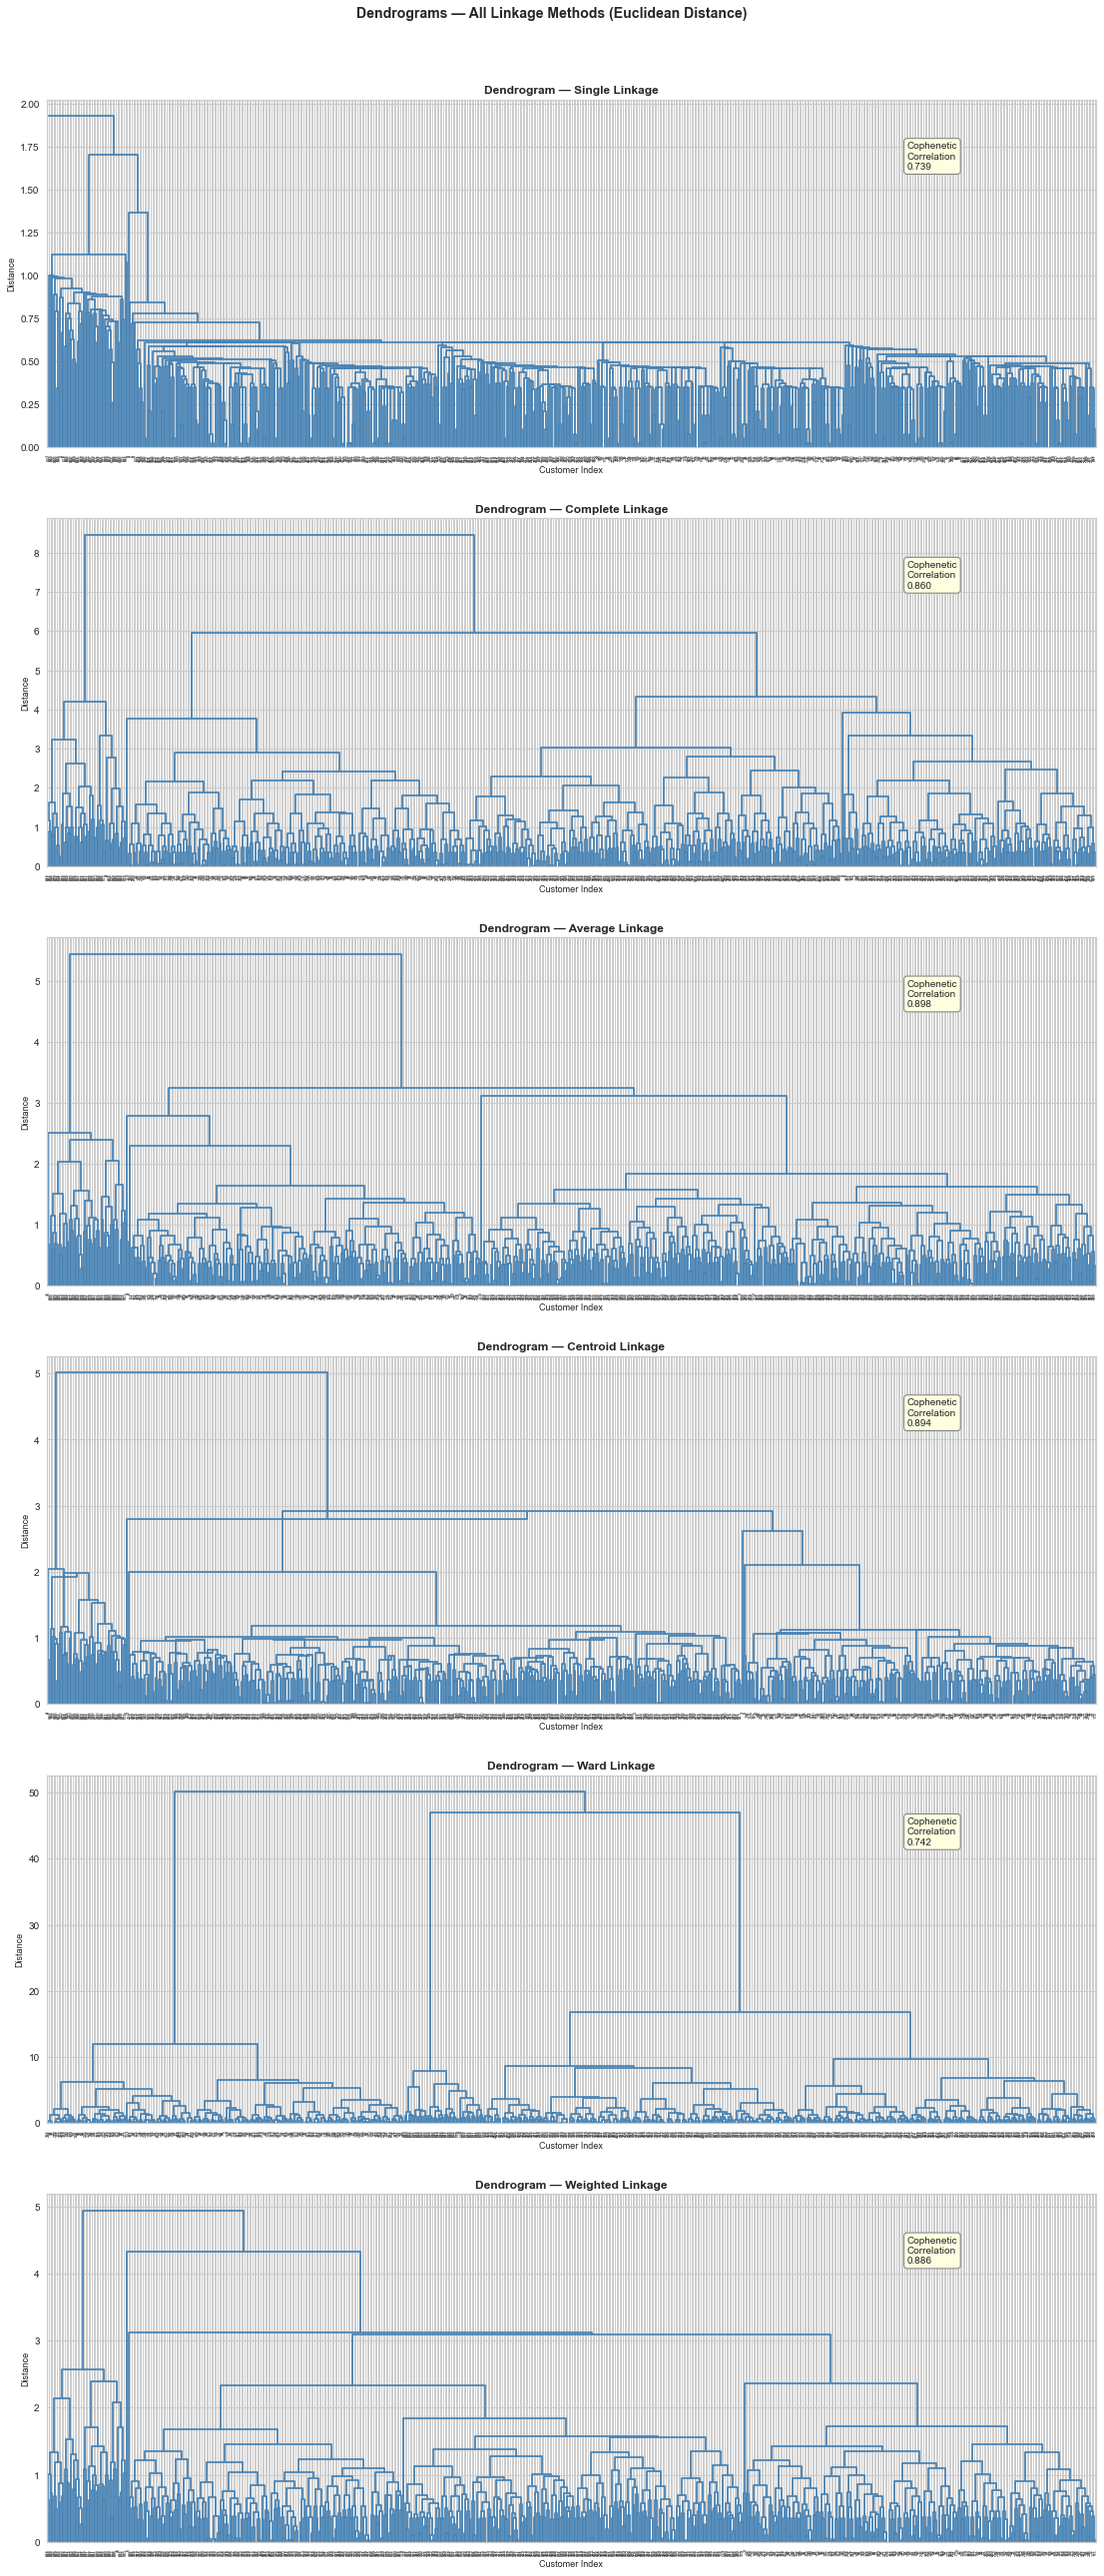

In [43]:
linkage_methods_eu = ["single", "complete", "average", "centroid", "ward", "weighted"]

fig, axs = plt.subplots(len(linkage_methods_eu), 1, figsize=(16, 36))

for i, method in enumerate(linkage_methods_eu):
    Z = linkage(df_scaled, metric="euclidean", method=method)
    dendrogram(Z, ax=axs[i], color_threshold=0,
               above_threshold_color='steelblue', leaf_font_size=4)
    axs[i].set_title(f"Dendrogram — {method.capitalize()} Linkage",
                     fontsize=12, fontweight='bold')
    axs[i].set_xlabel("Customer Index", fontsize=9)
    axs[i].set_ylabel("Distance", fontsize=9)
    coph_corr, _ = cophenet(Z, pdist(df_scaled))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:.3f}",
        xy=(0.82, 0.80), xycoords="axes fraction", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", lw=1)
    )

plt.suptitle("Dendrograms — All Linkage Methods (Euclidean Distance)",
             fontsize=14, fontweight='bold', y=1.002)
plt.tight_layout(pad=3.0)
plt.show()

> **Observation — Dendrograms:**
>
> - **Single Linkage (0.739)**: Produces a classic chaining effect — most customers are absorbed progressively into one large cluster. Not suitable for this dataset as it does not produce distinct groups.
> - **Complete Linkage (0.860)**: More balanced clusters with reasonable boundaries, but the separation between groups is not very pronounced.
> - **Average Linkage (0.898)**: Highest cophenetic correlation; the dendrogram shows reasonably compact clusters. Suggests approximately **3 clusters** as a meaningful cut point.
> - **Centroid Linkage (0.894)**: High cophenetic correlation; dendrogram structure is similar to average linkage.
> - **Ward Linkage (0.742)**: Although cophenetic correlation is lower, it produces the most **visually distinct and compact clusters** with the clearest gaps between major merges. A horizontal cut clearly suggests **3 clusters** — consistent with the K-Means result.
> - **Weighted Linkage (0.886)**: High cophenetic correlation; similar structure to complete linkage.
>
> **Decision: Ward linkage is selected for the final hierarchical clustering model**, as it produces the most visually distinct and compact clusters — making cluster interpretation most straightforward for business purposes.


### Ward Dendrogram — Determining Optimal Number of Clusters

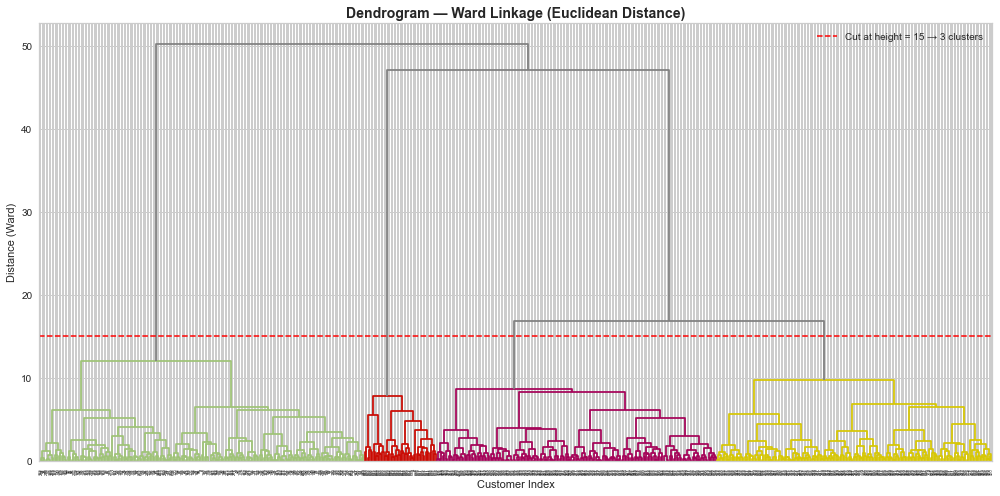

Ward Linkage — Cophenetic Correlation: 0.7415


In [44]:
Z_ward = linkage(df_scaled, metric="euclidean", method="ward")

plt.figure(figsize=(14, 7))
dendrogram(Z_ward, color_threshold=15, above_threshold_color='gray', leaf_font_size=4)
plt.title("Dendrogram — Ward Linkage (Euclidean Distance)", fontsize=14, fontweight='bold')
plt.xlabel("Customer Index", fontsize=11)
plt.ylabel("Distance (Ward)", fontsize=11)
plt.axhline(y=15, color='red', linestyle='--', linewidth=1.5,
            label='Cut at height = 15 → 3 clusters')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

coph_ward, _ = cophenet(Z_ward, pdist(df_scaled))
print(f"Ward Linkage — Cophenetic Correlation: {coph_ward:.4f}")

> **Observation — Ward Dendrogram (Final):**
>
> - The Ward dendrogram shows **3 clearly separated major cluster groups** when the tree is cut at an appropriate height. The three groups are visually well-defined with large vertical gaps before the final merge.
> - A horizontal cut at approximately height = 15 gives **3 well-separated clusters**, consistent with the K-Means findings.
> - Beyond 3 clusters, merge distances become significantly smaller, indicating that further splits would produce less meaningful sub-segments.
> - **K = 3 is therefore selected as the optimal number of clusters** for Hierarchical Clustering.


### Silhouette Score Validation for Hierarchical Clustering

Silhouette Scores — Hierarchical Clustering (Ward Linkage):

  n_clusters = 2:  Silhouette Score = 0.4177
  n_clusters = 3:  Silhouette Score = 0.5148
  n_clusters = 4:  Silhouette Score = 0.3481
  n_clusters = 5:  Silhouette Score = 0.2569
  n_clusters = 6:  Silhouette Score = 0.2268
  n_clusters = 7:  Silhouette Score = 0.2163
  n_clusters = 8:  Silhouette Score = 0.2187


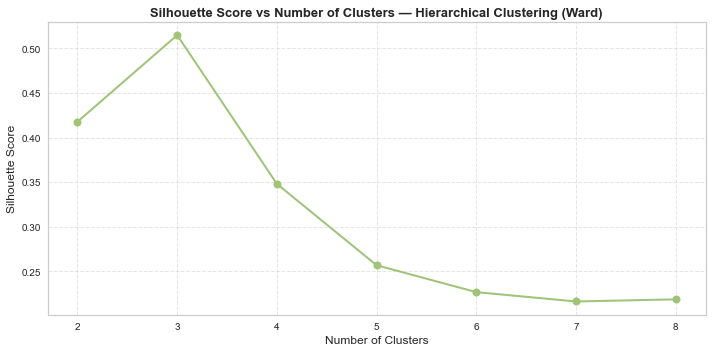

In [45]:
hc_sil_scores = []
hc_cluster_list = list(range(2, 9))

print("Silhouette Scores — Hierarchical Clustering (Ward Linkage):\n")

for n_clusters in hc_cluster_list:
    hc_model = AgglomerativeClustering(n_clusters=n_clusters,
                                        metric="euclidean", linkage="ward")
    labels = hc_model.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    hc_sil_scores.append(score)
    print(f"  n_clusters = {n_clusters}:  Silhouette Score = {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(hc_cluster_list, hc_sil_scores, 'go-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters — Hierarchical Clustering (Ward)',
          fontsize=13, fontweight='bold')
plt.xticks(hc_cluster_list)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> **Observation — HC Silhouette Scores:**
>
> - The silhouette score for Hierarchical Clustering (Ward linkage) peaks at **K=3 (0.5148)**, with K=2 being notably lower (0.4177) — unlike K-Means where K=2 scored highest. This confirms that **Ward linkage naturally identifies 3 as the optimal cluster count**.
> - Scores decline steadily for K=4 and beyond, reinforcing that splitting into more than 3 clusters introduces noise rather than meaningful segments.
> - The alignment between the dendrogram visual cut at 3 clusters and the silhouette score peak at K=3 strongly validates **3 as the optimal cluster count** for Hierarchical Clustering.


### Final Hierarchical Clustering Model

In [46]:
hc_final = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
hc_final.fit(df_scaled)

df['HC_Cluster'] = hc_final.labels_

print("Hierarchical Clustering complete.")
print("\nCluster distribution:")
print(df['HC_Cluster'].value_counts().sort_index())

Hierarchical Clustering complete.

Cluster distribution:
HC_Cluster
0    385
1    225
2     50
Name: count, dtype: int64


### Hierarchical Clustering — Cluster Profiling

In [47]:
hc_profile = df.groupby('HC_Cluster')[num_cols].mean()

hc_profile['count_in_cluster'] = (
    df.groupby('HC_Cluster')['Avg_Credit_Limit'].count().values
)

print("Hierarchical Clustering Cluster Profile:")
hc_profile

Hierarchical Clustering Cluster Profile:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_cluster
HC_Cluster,,,,,,
0,33851.948,5.517,3.494,0.979,1.995,385
1,12151.111,2.422,0.938,3.547,6.858,225
2,141040.000,8.740,0.600,10.900,1.080,50


In [48]:
hc_profile.style.highlight_max(color='lightgreen', axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_cluster
HC_Cluster,,,,,,
0,33851.948052,5.516883,3.493506,0.979221,1.994805,385
1,12151.111111,2.422222,0.937778,3.546667,6.857778,225
2,141040.000000,8.740000,0.600000,10.900000,1.080000,50


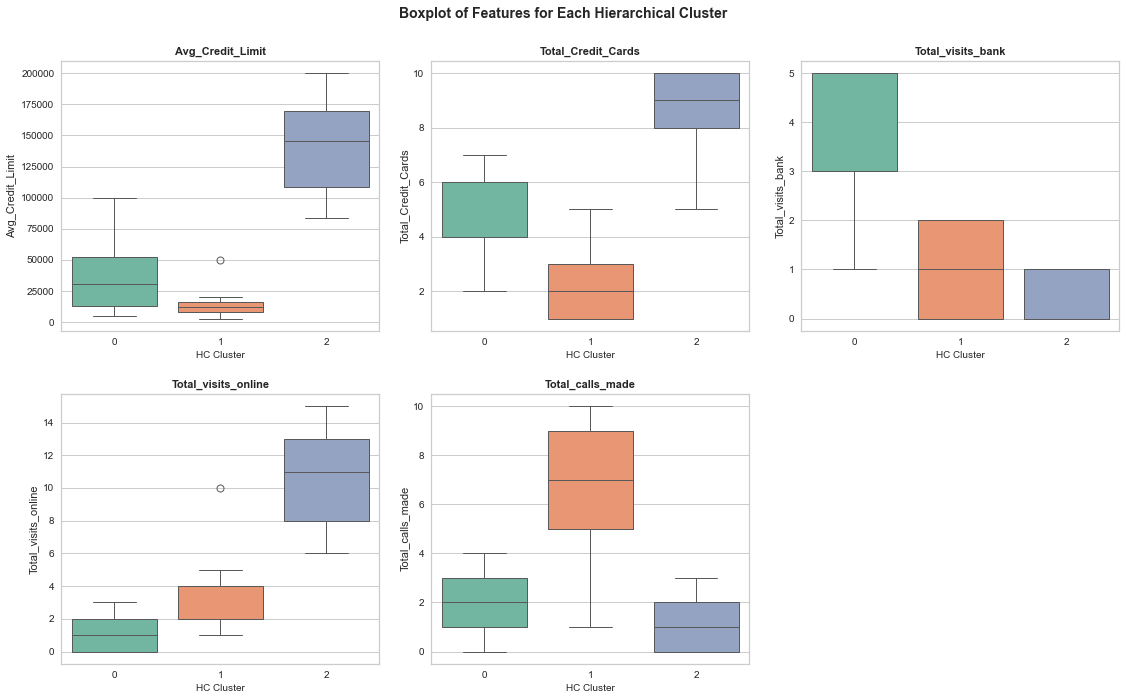

In [49]:
plt.figure(figsize=(16, 10))
plt.suptitle("Boxplot of Features for Each Hierarchical Cluster",
             fontsize=14, fontweight='bold')

for i, variable in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df, x='HC_Cluster', y=variable, palette='Set2')
    plt.title(variable, fontsize=11, fontweight='bold')
    plt.xlabel('HC Cluster', fontsize=10)

plt.tight_layout(pad=2.0)
plt.show()

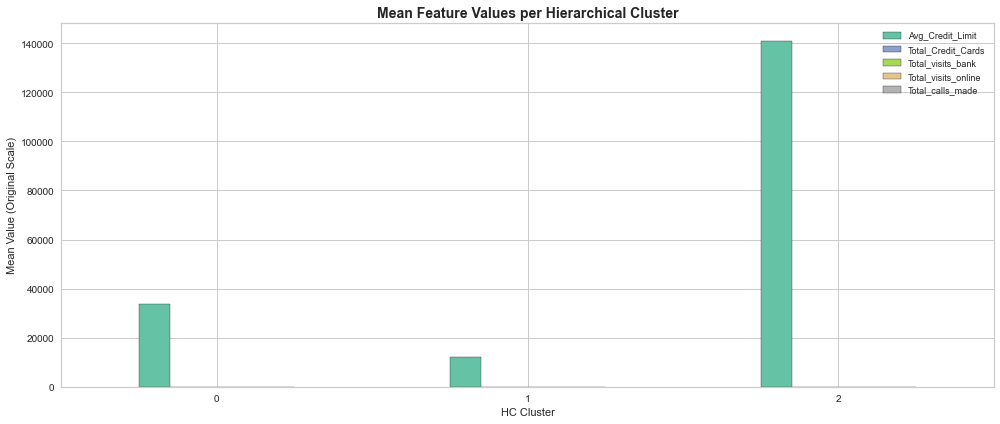

In [50]:
df.groupby('HC_Cluster')[num_cols].mean().plot.bar(
    figsize=(14, 6), colormap='Set2', edgecolor='black')
plt.title('Mean Feature Values per Hierarchical Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Mean Value (Original Scale)', fontsize=11)
plt.xlabel('HC Cluster', fontsize=11)
plt.xticks(rotation=0)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

> **Hierarchical Clustering — Cluster Profiling Observations:**
>
> The HC cluster profiles are almost identical to the K-Means profiles, further validating the stability of the three segments:
>
> **HC Cluster 0 — Mid-Value, Branch-Preferring Customers (385 customers):**
> - Mid-range average credit limit (₹33,852) and moderate number of credit cards (~5.5).
> - **Highest bank visit frequency** (~3.5 visits/year) — strong in-person banking preference.
> - Very low online visits (1.0/year) and low call frequency (~2.0/year).
> - Corresponds almost exactly to K-Means Cluster 0, confirming the stability of this segment.
>
> **HC Cluster 1 — Low-Value, Call-Heavy Customers (225 customers):**
> - Lowest average credit limit (₹12,151) and fewest credit cards (~2.4).
> - **Highest call frequency** (~6.9 calls/year) — primary drivers of call center load and service complaints.
> - Moderate online engagement (3.5/year) but very low branch visits (~0.9/year).
> - Corresponds almost exactly to K-Means Cluster 1.
>
> **HC Cluster 2 — High-Value, Digital-First Customers (50 customers):**
> - **Highest average credit limit** (₹141,040) and most credit cards (~8.7) — the premium segment.
> - **Highest online visit frequency** (~10.9 visits/year) — almost entirely digital in their banking behavior.
> - Fewest bank visits (0.6/year) and very low call frequency (~1.1/year).
> - Identical to K-Means Cluster 2 — every single customer in this segment is assigned to the same cluster by both methods.


## K-Means vs. Hierarchical Clustering — Comparison

Having applied both clustering techniques, we now compare their results across several dimensions.

### Cluster Agreement Analysis

In [51]:
print("Cross-tabulation — K-Means vs Hierarchical Clustering Labels:\n")
ct = pd.crosstab(df['KMeans_Cluster'], df['HC_Cluster'],
                 rownames=['K-Means Cluster'], colnames=['HC Cluster'])
print(ct)

Cross-tabulation — K-Means vs Hierarchical Clustering Labels:

HC Cluster         0    1   2
K-Means Cluster              
0                385    1   0
1                  0  224   0
2                  0    0  50


In [52]:
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['KMeans_Cluster'], df['HC_Cluster'])
print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print("(ARI closer to 1.0 → high agreement between the two methods)")


Adjusted Rand Index (ARI): 0.9944
(ARI closer to 1.0 → high agreement between the two methods)


In [53]:
kmeans_sil = silhouette_score(df_scaled, df['KMeans_Cluster'])
hc_sil     = silhouette_score(df_scaled, df['HC_Cluster'])

print("\nSilhouette Score Comparison:")
print(f"  K-Means Clustering        : {kmeans_sil:.4f}")
print(f"  Hierarchical Clustering   : {hc_sil:.4f}")


Silhouette Score Comparison:
  K-Means Clustering        : 0.5157
  Hierarchical Clustering   : 0.5148


In [54]:
km_counts = df['KMeans_Cluster'].value_counts().sort_index()
hc_counts = df['HC_Cluster'].value_counts().sort_index()

comparison_df = pd.DataFrame({
    'K-Means Count': km_counts.values,
    'HC Count'     : hc_counts.values
}, index=['Cluster 0', 'Cluster 1', 'Cluster 2'])

print("\nCluster Size Comparison:")
print(comparison_df)


Cluster Size Comparison:
           K-Means Count  HC Count
Cluster 0            386       385
Cluster 1            224       225
Cluster 2             50        50


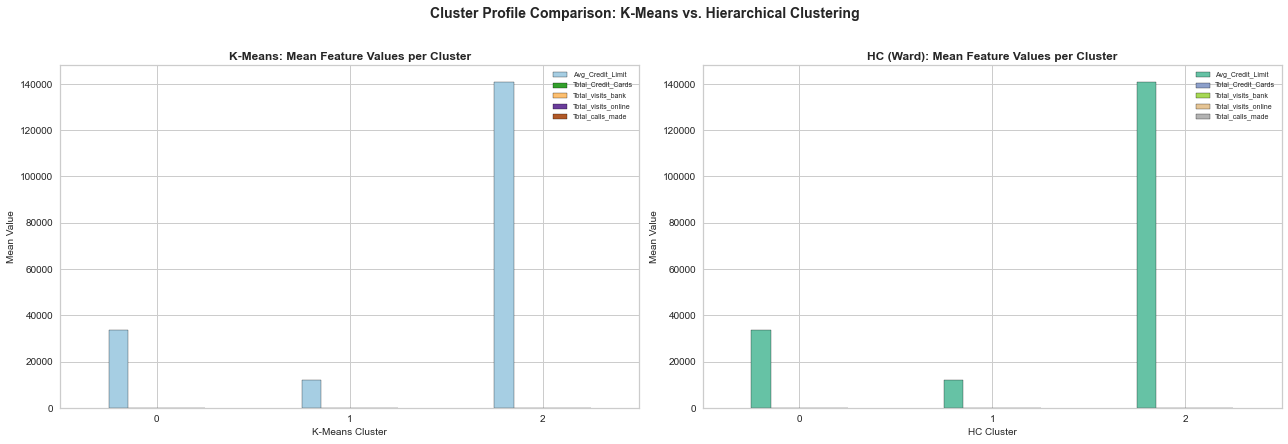

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df.groupby('KMeans_Cluster')[num_cols].mean().plot.bar(
    ax=axes[0], colormap='Paired', edgecolor='black')
axes[0].set_title('K-Means: Mean Feature Values per Cluster',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('K-Means Cluster', fontsize=10)
axes[0].set_ylabel('Mean Value', fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(loc='upper right', fontsize=7)

df.groupby('HC_Cluster')[num_cols].mean().plot.bar(
    ax=axes[1], colormap='Set2', edgecolor='black')
axes[1].set_title('HC (Ward): Mean Feature Values per Cluster',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('HC Cluster', fontsize=10)
axes[1].set_ylabel('Mean Value', fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(loc='upper right', fontsize=7)

plt.suptitle('Cluster Profile Comparison: K-Means vs. Hierarchical Clustering',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **K-Means vs. Hierarchical Clustering — Key Comparison:**
>
> | Criterion | K-Means | Hierarchical Clustering (Ward) |
> |---|---|---|
> | **Optimal Clusters** | 3 | 3 |
> | **Silhouette Score** | 0.5157 | 0.5148 |
> | **Cluster Interpretability** | High | High (aided by dendrogram) |
> | **Scalability** | Faster for large data | Slower — O(n²) memory |
> | **Requires K upfront** | Yes | No — dendrogram guides selection |
> | **Sensitivity to initialization** | Yes (mitigated by random_state) | No |
> | **Agreement (ARI)** | — | 0.9944 (near perfect) |
>
> **Observations:**
>
> - Both algorithms converge on **3 as the optimal number of clusters**, providing strong mutual validation. The **Adjusted Rand Index of 0.9944** confirms near-perfect agreement between the two solutions — only 1 customer is assigned differently between the two methods.
> - The three segment profiles — **Low-Value/Call-Heavy (Cluster 1), Mid-Value/Branch-Preferring (Cluster 0), and High-Value/Digital-First (Cluster 2)** — emerge identically from both methods, confirming these are genuine, stable customer segments in the data.
> - **K-Means yields a marginally higher silhouette score (0.5157 vs 0.5148)**, but the difference is negligible. Both methods are essentially equivalent in cluster quality.
> - **Hierarchical Clustering provides the added advantage of the dendrogram**, offering a visual, assumption-free way to determine cluster count. Notably, the HC silhouette score peaks at K=3 (not K=2 like K-Means), making the cluster count decision more straightforward with HC.
> - **K-Means is preferred for deployment** given its faster execution time and ease of assigning new customers to clusters using trained centroids. However, both methods yield fully equivalent and actionable business insights.


## Actionable Insights and Recommendations

Both clustering techniques consistently and reliably identify **3 meaningful customer segments**. The following insights and recommendations address the dual business objectives of improving marketing effectiveness and upgrading service delivery.

---

### Segment Summary

| Segment | Profile Label | Avg Credit Limit | Credit Cards | Bank Visits | Online Visits | Calls Made | Size |
|---|---|---|---|---|---|---|---|
| Cluster 0 | Mid-Value, Branch-Preferring | ~₹33,800 | ~5.5 | ~3.5 (Highest) | ~1.0 (Lowest) | ~2.0 | 386 (58%) |
| Cluster 1 | Low-Value, Call-Heavy | ~₹12,200 | ~2.4 (Lowest) | ~0.9 | ~3.5 | ~6.9 (Highest) | 224 (34%) |
| Cluster 2 | High-Value, Digital-First | ~₹141,040 (Highest) | ~8.7 (Highest) | ~0.6 (Lowest) | ~10.9 (Highest) | ~1.1 (Lowest) | 50 (8%) |

---


### Segment 1 — Low-Value, Call-Heavy Customers (Cluster 1 — 34% of customers)

**Profile:** These customers have the lowest credit limits, fewest credit cards, and make by far the most calls to the bank (~6.9/year). They use online channels moderately but rarely visit branches. Their high call frequency strongly suggests recurring service frustration or unresolved queries.

**Marketing Recommendations:**
- Run targeted campaigns for **credit limit enhancement** and **entry-level credit card upgrade offers** to grow this segment's financial relationship with the bank.
- Offer **educational content** (FAQs, how-to videos, chatbot assistance) to help them become more self-sufficient.
- Use **loyalty incentives** (cashback, reward points) to deepen engagement and improve product holding.
- Since they use online channels moderately, **digital nudges and SMS campaigns** can be effective reach mechanisms.

**Operations Recommendations:**
- Prioritize this cluster for the **service delivery model upgrade** — they are the primary drivers of call center volume.
- Implement **proactive outreach** (SMS/email alerts for billing cycles, payment reminders, common query resolution) to reduce reactive calls.
- Introduce **IVR/chatbot self-service options** tailored to this segment's most frequent query types.
- Assign dedicated **customer care representatives** with faster escalation paths and first-call resolution targets.

---

### Segment 2 — Mid-Value, Branch-Preferring Customers (Cluster 0 — 58% of customers)

**Profile:** The largest segment. These customers have mid-range credit limits, moderate card holdings, and the highest branch visit frequency (~3.5/year). They rarely use online banking, indicating a strong preference for in-person service.

**Marketing Recommendations:**
- Roll out **in-branch personalized offers** — these customers are most receptive to face-to-face engagement.
- Cross-sell products such as **fixed deposits, insurance, or investment plans** during branch visits, as these interactions offer a captive audience.
- Introduce **relationship manager assignments** to deepen personal connections and grow product holding.
- Gradually nudge this segment toward **digital adoption** through branch-led digital onboarding sessions with incentives for first-time digital transactions.

**Operations Recommendations:**
- Ensure **branch staffing levels and service quality** are optimized for this segment — their satisfaction is highly dependent on in-person experience.
- Invest in **branch ambience and queue management systems** to reduce wait times.
- Train branch staff to **proactively cross-sell and identify upsell opportunities** during visits.

---

### Segment 3 — High-Value, Digital-First Customers (Cluster 2 — 8% of customers)

**Profile:** The smallest but most valuable segment. These customers have the highest credit limits (₹1.4 lakh), hold the most credit cards (8.7), and are almost entirely digital in their banking behavior (~10.9 online visits/year). They rarely call or visit branches — highly self-sufficient.

**Marketing Recommendations:**
- Focus on **upselling premium credit card products** (co-branded cards, travel rewards, concierge services, airport lounge access, forex benefits).
- Offer **exclusive digital banking features** such as higher credit lines, wealth management products, and priority banking app features.
- Design **highly personalized digital campaigns** (in-app notifications, email personalization based on spending patterns) as this segment is most reachable through digital channels.
- Introduce a **premium loyalty program** with tiered rewards and exclusive privileges to retain this high-value group.

**Operations Recommendations:**
- Ensure the **digital banking platform is robust, fast, secure, and feature-rich** to match these customers' high digital expectations.
- Offer a **dedicated priority helpline** (with near-zero wait times) as a fallback, even though this segment calls infrequently.
- Provide **proactive digital notifications** (spending insights, credit limit review prompts, investment opportunities) to enhance engagement further.

---

### Overall Strategic Recommendations

1. **Segment-Specific Communication Strategy**: Adopt a channel-specific marketing approach — digital campaigns for Cluster 2, in-branch engagement for Cluster 0, and assisted digital/call-based outreach for Cluster 1.
2. **Reduce Call Center Load Immediately**: Cluster 1 (34% of customers) generates a disproportionate share of inbound calls. Proactive communication, self-service tools, and faster query resolution will directly address the Operations team's service delivery concern and reduce operational costs.
3. **Protect and Grow High-Value Customers**: Cluster 2 (~8% of customers) represents the bank's premium revenue base. Retention investments here yield the highest ROI. Any degradation in digital service quality risks losing these customers to competitors.
4. **Bridge the Digital Gap for Cluster 0**: The largest segment (~58%) is almost entirely branch-dependent. A phased digital adoption strategy — incentivized through in-branch interactions — will future-proof the bank and reduce long-term branch operating costs.
5. **Monitor Segment Migration**: Re-run clustering quarterly or semi-annually to detect customer movement across segments. For example, if Cluster 1 customers begin reducing calls after service improvements, this directly quantifies the Operations team's impact and ROI.
6. **Revenue Prioritization Framework**: While Cluster 2 is smallest by count, it should receive the highest per-customer investment. Cluster 0 should receive the highest total investment given its size (58%). Cluster 1 requires urgent operational investment to reduce costs and improve satisfaction before marketing investment can be effective.
